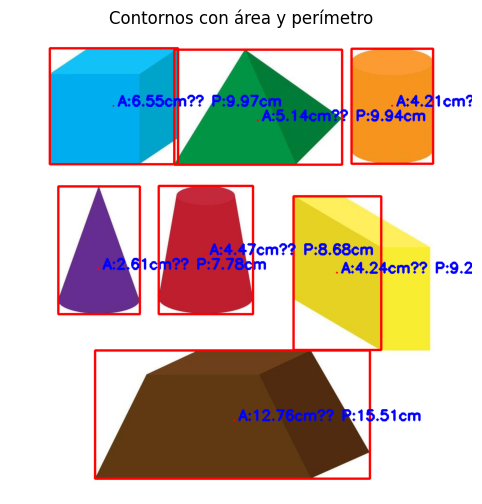

Contorno 1: Perímetro = 15.51Cm, Área = 12.76Cm
Contorno 2: Perímetro = 9.28Cm, Área = 4.24Cm
Contorno 3: Perímetro = 7.78Cm, Área = 2.61Cm
Contorno 4: Perímetro = 8.68Cm, Área = 4.47Cm
Contorno 5: Perímetro = 9.94Cm, Área = 5.14Cm
Contorno 6: Perímetro = 7.98Cm, Área = 4.21Cm
Contorno 7: Perímetro = 9.97Cm, Área = 6.55Cm


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\objetos5.jpg"
imagen = cv2.imread(ruta)
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

ret, bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

contornos, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

perimetros = []
areas = []

pixeles_por_cm = None 

for i in range(len(contornos)):
    cnt = contornos[i]
    M = cv2.moments(cnt)
    
    if M['m00'] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt, True)

    x, y, w, h = cv2.boundingRect(cnt)

    if i == 0:
        ancho_real_cm = 6  
        pixeles_por_cm = w / ancho_real_cm

    if pixeles_por_cm is not None:
        perimetro_cm = perimetro / pixeles_por_cm
        area_cm2 = area / (pixeles_por_cm ** 2)
    else:
        perimetro_cm = perimetro
        area_cm2 = area

    areas.append(area_cm2)
    perimetros.append(perimetro_cm)

    # Dibujo y texto
    cv2.rectangle(imagen, (x, y), (x + w, y + h), (0, 0, 255), 3)
    cv2.circle(imagen, (cx, cy), 2, (0, 0, 255), -1)
    cv2.putText(imagen, f"A:{area_cm2:.2f}cm² P:{perimetro_cm:.2f}cm", (cx + 10, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)


imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(imagen_rgb)
plt.axis('off')
plt.title("Contornos con área y perímetro")
plt.show()

for i, (perimetro, area) in enumerate(zip(perimetros, areas)):
    print(f"Contorno {i + 1}: Perímetro = {perimetro:.2f}Cm, Área = {area:.2f}Cm")



Practica Individual

Figura 1
Tipo: Circulo,Vertices: 6,Centroide: (475, 823),Hu: [np.float64(0.1989), np.float64(0.0117), np.float64(0.0008), np.float64(0.0001), np.float64(-0.0), np.float64(-0.0), np.float64(0.0)]
Figura 2
Tipo: Rectangulo,Vertices: 4,Centroide: (693, 510),Hu: [np.float64(0.1934), np.float64(0.0096), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(-0.0)]
Figura 3
Tipo: Rectangulo,Vertices: 4,Centroide: (187, 502),Hu: [np.float64(0.2113), np.float64(0.0107), np.float64(0.0043), np.float64(0.0006), np.float64(0.0), np.float64(0.0001), np.float64(-0.0)]
Figura 4
Tipo: Circulo,Vertices: 5,Centroide: (414, 471),Hu: [np.float64(0.1832), np.float64(0.0058), np.float64(0.0005), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Figura 5
Tipo: Rectangulo,Vertices: 4,Centroide: (525, 187),Hu: [np.float64(0.1833), np.float64(0.003), np.float64(0.0015), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Figura 6
Tipo: Circulo,Vertices:

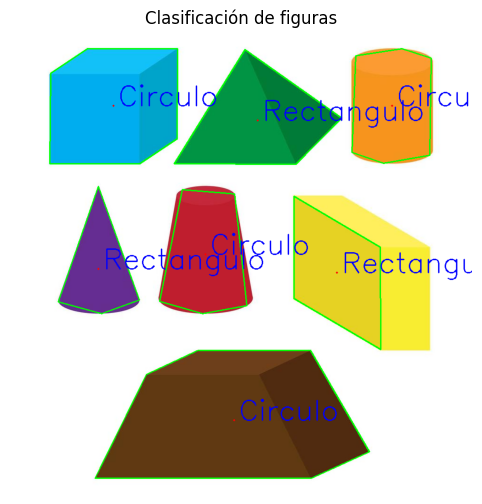

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\objetos5.jpg"
imagen = cv2.imread(ruta)
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

ret, bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

contornos, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for i in range(len(contornos)):
    cnt = contornos[i]

    M = cv2.moments(cnt)
    hu = cv2.HuMoments(M)

    if M['m00'] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    vertices = len(approx)

    if vertices == 3:
        forma = "Triangulo"
    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        if 0.95 <= aspect_ratio <= 1.05:
            forma = "Cuadrado"
        else:
            forma = "Rectangulo"
    elif vertices > 4:
        forma = "Circulo"
    else:
        forma = "Desconocido"

    cv2.drawContours(imagen, [approx], -1, (0, 255, 0), 2)
    cv2.circle(imagen, (cx, cy), 2, (0, 0, 255), -1)
    cv2.putText(imagen, forma, (cx + 10, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 0, 0), 2)

    print(f"Figura {i+1}\nTipo: {forma},Vertices: {vertices},Centroide: ({cx}, {cy}),Hu: {[round(v[0],4) for v in hu]}")


imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(imagen_rgb)
plt.axis('off')
plt.title("Clasificación de figuras")
plt.show()
